In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import numpy as np
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, 
    precision_score, recall_score
)

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate

warnings.filterwarnings("ignore")

## Датасет [Jungle](https://www.openml.org/search?type=data&status=active&id=41027)

In [2]:
dataset_id = 41027
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_lr = model_lr.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lr.predict_proba(X_test), multi_class="ovr", average="macro"))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr, average="macro"))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr, average="macro"))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr, average="macro"))

[I 2025-04-14 20:18:40,913] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-14 20:18:40,982] Trial 0 finished with value: 0.8034416094867418 and parameters: {'penalty': 'l2', 'C': 10}. Best is trial 0 with value: 0.8034416094867418.
[I 2025-04-14 20:18:41,076] Trial 1 finished with value: 0.8032642858654641 and parameters: {'penalty': 'l2', 'C': 0.0001}. Best is trial 0 with value: 0.8034416094867418.
[I 2025-04-14 20:18:41,186] Trial 2 finished with value: 0.8034527808192338 and parameters: {'penalty': 'l2', 'C': 0.1}. Best is trial 2 with value: 0.8034527808192338.
[I 2025-04-14 20:18:41,249] Trial 3 finished with value: 0.8034527808192338 and parameters: {'penalty': 'l2', 'C': 0.1}. Best is trial 2 with value: 0.8034527808192338.
[I 2025-04-14 20:18:41,314] Trial 4 finished with value: 0.8034412334224901 and parameters: {'penalty': 'l2', 'C': 100}. Best is trial 2 with value: 0.8034527808192338.
[I 2025-04-14 20:18:41,383] Trial 5 finished with v

ROC-AUC = 0.8148
F1 = 0.4849
Accuracy = 0.6847
Precision = 0.5723
Recall = 0.5024


In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_cb = model_cb.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_cb.predict_proba(X_test), multi_class="ovr", average="macro"))
print("F1 = %.4f" % f1_score(y_test, y_pred_cb, average="macro"))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_cb))
print("Precision = %.4f" % precision_score(y_test, y_pred_cb, average="macro"))
print("Recall = %.4f" % recall_score(y_test, y_pred_cb, average="macro"))

[I 2025-04-14 20:18:42,467] A new study created in memory with name: catboost_optimization
[I 2025-04-14 20:18:45,278] Trial 0 finished with value: 0.9741083639160181 and parameters: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 1.0}. Best is trial 0 with value: 0.9741083639160181.
[I 2025-04-14 20:18:49,309] Trial 1 finished with value: 0.9746194033644652 and parameters: {'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 0.01}. Best is trial 1 with value: 0.9746194033644652.
[I 2025-04-14 20:18:54,660] Trial 2 finished with value: 0.9729722911137652 and parameters: {'depth': 10, 'learning_rate': 0.01, 'l2_leaf_reg': 1.0}. Best is trial 1 with value: 0.9746194033644652.
[I 2025-04-14 20:18:57,216] Trial 3 finished with value: 0.8493870346269198 and parameters: {'depth': 4, 'learning_rate': 0.001, 'l2_leaf_reg': 0.001}. Best is trial 1 with value: 0.9746194033644652.
[I 2025-04-14 20:19:02,493] Trial 4 finished with value: 0.9560927245460557 and parameters: {'depth': 10, 'learning_r

ROC-AUC = 0.9757
F1 = 0.8211
Accuracy = 0.8635
Precision = 0.8335
Recall = 0.8107


In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_lgbm = model_lgbm.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lgbm.predict_proba(X_test), multi_class="ovr", average="macro"))
print("F1 = %.4f" % f1_score(y_test, y_pred_lgbm, average="macro"))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lgbm))
print("Precision = %.4f" % precision_score(y_test, y_pred_lgbm, average="macro"))
print("Recall = %.4f" % recall_score(y_test, y_pred_lgbm, average="macro"))

[I 2025-04-14 20:19:56,424] A new study created in memory with name: lightgbm_optimization
[I 2025-04-14 20:20:02,007] Trial 0 finished with value: 0.9757978518936575 and parameters: {'num_leaves': 512, 'reg_alpha': 10.0, 'reg_lambda': 1.0, 'learning_rate': 0.03}. Best is trial 0 with value: 0.9757978518936575.
[I 2025-04-14 20:20:04,743] Trial 1 finished with value: 0.9802231712883493 and parameters: {'num_leaves': 16, 'reg_alpha': 1e-06, 'reg_lambda': 1e-07, 'learning_rate': 0.1}. Best is trial 1 with value: 0.9802231712883493.
[I 2025-04-14 20:20:06,788] Trial 2 finished with value: 0.9753548589720724 and parameters: {'num_leaves': 16, 'reg_alpha': 10.0, 'reg_lambda': 10.0, 'learning_rate': 0.1}. Best is trial 1 with value: 0.9802231712883493.
[I 2025-04-14 20:20:30,454] Trial 3 finished with value: 0.9752107601073413 and parameters: {'num_leaves': 256, 'reg_alpha': 1e-06, 'reg_lambda': 10.0, 'learning_rate': 0.03}. Best is trial 1 with value: 0.9802231712883493.
[I 2025-04-14 20:20

ROC-AUC = 0.9819
F1 = 0.8342
Accuracy = 0.8815
Precision = 0.8463
Recall = 0.8240


In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


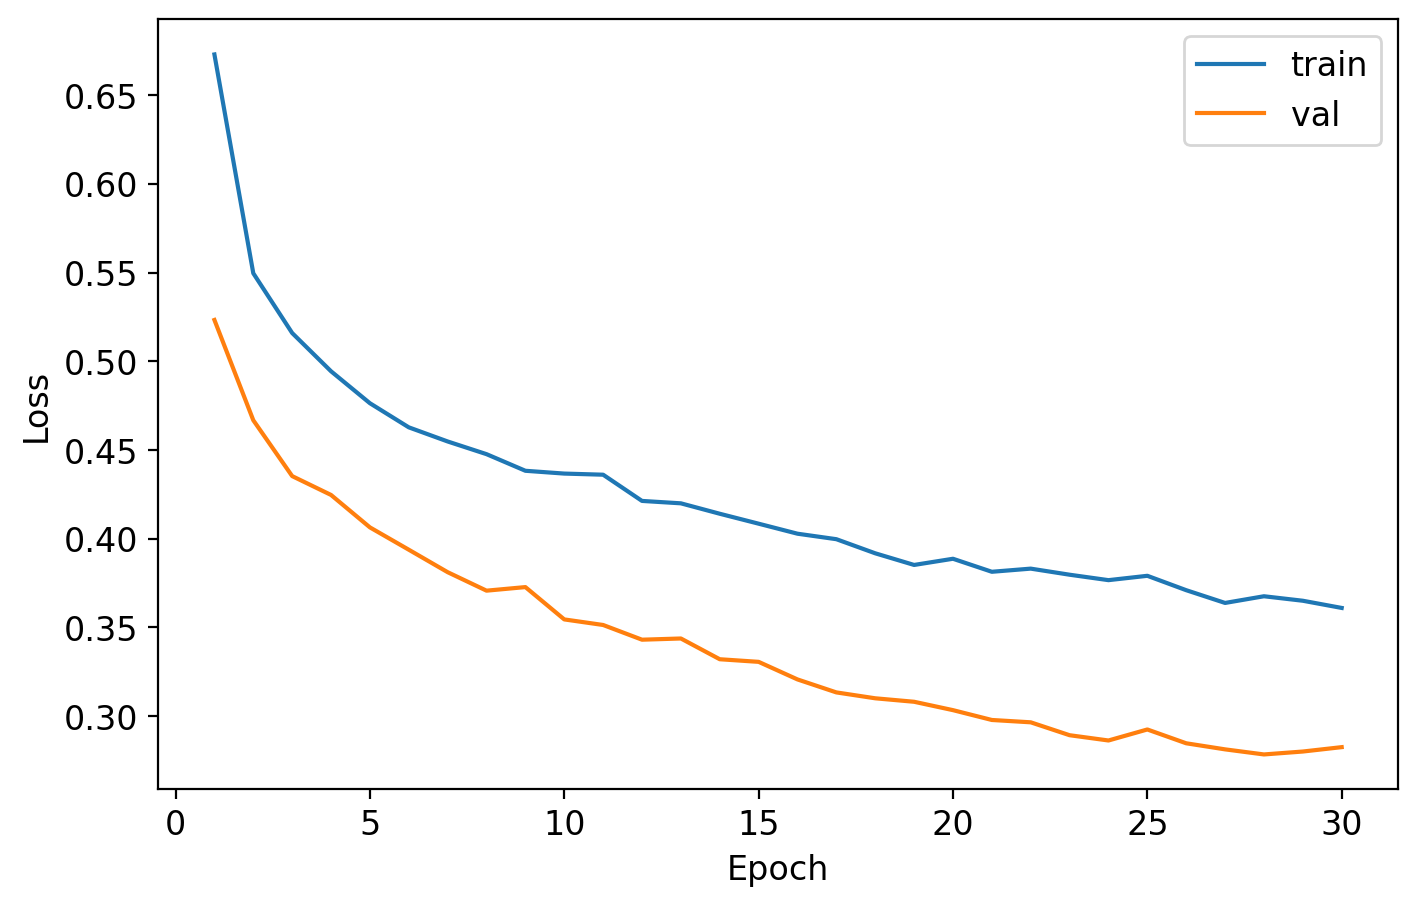

Epoch 30: train loss = 0.3610; valid loss = 0.2825


In [11]:
net = TABMLP(len(numerical_features), emb_dims, num_classes=len(np.unique(y_train))).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 30, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device, multi=True)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro"))
print("F1 = %.4f" % f1_score(y_test, y_pred, average="macro"))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred))
print("Precision = %.4f" % precision_score(y_test, y_pred, average="macro"))
print("Recall = %.4f" % recall_score(y_test, y_pred, average="macro"))

ROC-AUC = 0.9724
F1 = 0.8182
Accuracy = 0.8610
Precision = 0.8218
Recall = 0.8149
